In [50]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt


In [51]:
# upload data
from google.colab import files
uploaded=files.upload()
df=pd.read_csv("nvb_patient_outcomes.csv")
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")


Saving nvb_patient_outcomes.csv to nvb_patient_outcomes (4).csv
Loaded: 360 rows, 10 columns


In [52]:
# view dataset
print("First 5 Rows:")
print (df.head())

First 5 Rows:
  patient_id age_group              diagnosis    treatment_type  \
0      P0001     60-74      Orthopedic Injury   Medication Only   
1      P0002     18-29  Neurological Disorder  Physical Therapy   
2      P0003     45-59        Type 2 Diabetes  Physical Therapy   
3      P0004     30-44          Mental Health           Surgery   
4      P0005     30-44   Cancer - Early Stage  Combined Therapy   

  insurance_type  length_of_stay_days  previous_admissions  \
0       Medicare                  7.7                    1   
1       Medicare                  5.1                    3   
2    Military/VA                  9.5                    2   
3        Private                  3.5                    4   
4      Uninsured                  NaN                    2   

   complication_occurred  readmitted_30days  patient_satisfaction  
0                      0                  0                   3.7  
1                      0                  0                   4.6  
2     

In [54]:
# check for missing values
print("Missing Values")
print(df.isnull().sum())

Missing Values
patient_id                0
age_group                 0
diagnosis                 0
treatment_type            0
insurance_type            5
length_of_stay_days       7
previous_admissions       0
complication_occurred     0
readmitted_30days         0
patient_satisfaction     14
dtype: int64


In [55]:
#Create a function for readmission
def average_readmission(data, column):
    #Returns the average 30-day readmission rate for each category
    average = data.groupby(column)["readmitted_30days"].mean()
    return average

In [56]:
# readmission rate by diagnosis
diagnosis_avg = average_readmission(df, "diagnosis")

print("30-Day Readmission Rate by Diagnosis")
print(diagnosis_avg)

30-Day Readmission Rate by Diagnosis
diagnosis
Cancer - Early Stage      0.177778
Cardiovascular Disease    0.236842
Hypertension              0.191489
Mental Health             0.130435
Neurological Disorder     0.139535
Orthopedic Injury         0.179487
Respiratory Infection     0.125000
Type 2 Diabetes           0.185185
Name: readmitted_30days, dtype: float64


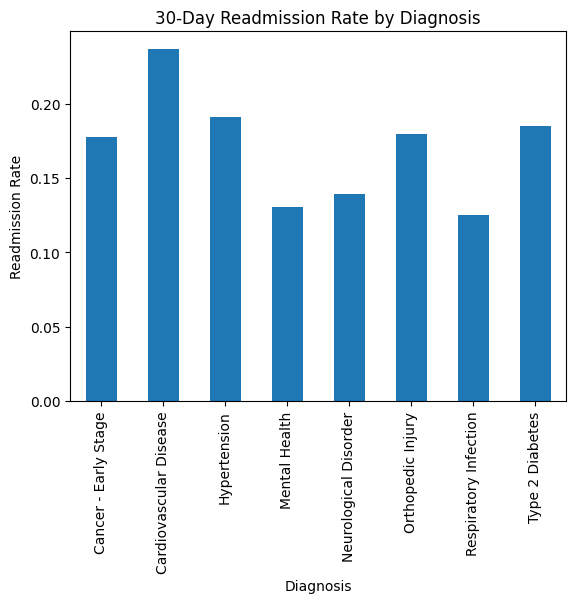

In [45]:
#Graph readmission rate by diagnosis
diagnosis_avg.plot(kind="bar")

plt.title("30-Day Readmission Rate by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Readmission Rate")

plt.show()

In [41]:
#Readmission rate by age group

age_avg = average_readmission(df, "age_group")

print("30-Day Readmission Rate by Age Group")
print(age_avg)

30-Day Readmission Rate by Age Group
age_group
18-29    0.069767
30-44    0.171875
45-59    0.193182
60-74    0.188679
75+      0.169492
Name: readmitted_30days, dtype: float64


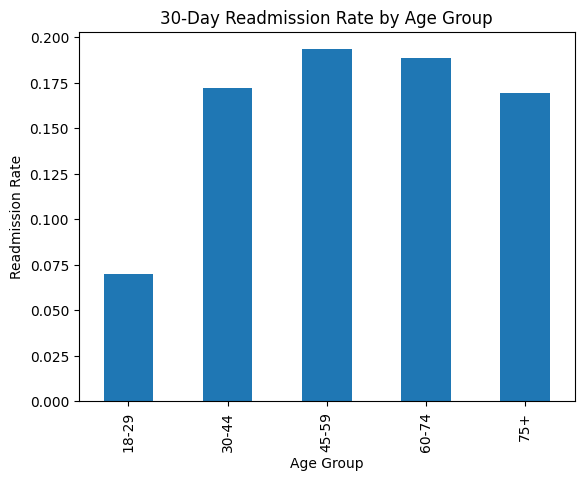

In [42]:
#Graph 2 readmission rate by age group
age_avg.plot(kind="bar")

plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate")

plt.show()

In [43]:
# highest readmission rate
print("Diagnosis with Highest Readmission Rate:")
print(diagnosis_avg.idxmax())

print()

print("Age Group with Highest Readmission Rate:")
print(age_avg.idxmax())

Diagnosis with Highest Readmission Rate:
Cardiovascular Disease

Age Group with Highest Readmission Rate:
45-59


In [46]:
#summary
print("--------------- SUMMARY ---------------")
print()

print("This project analyzed 30-day hospital readmission rates.")

print()

print("The diagnosis with the highest readmission rate was")
print(diagnosis_avg.idxmax())

print()

print("The age group with the highest readmission rate was")
print(age_avg.idxmax())

print()

print("These results show that some diagnoses and age groups")
print("have higher readmission rates than others.")


--------------- SUMMARY ---------------

This project analyzed 30-day hospital readmission rates.

The diagnosis with the highest readmission rate was
Cardiovascular Disease

The age group with the highest readmission rate was
45-59

These results show that some diagnoses and age groups
have higher readmission rates than others.
